In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, DotProduct, ExpSineSquared, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')
plt.rcParams.update({
    'font.serif': 'Times New Roman',
    'axes.unicode_minus': False,
    'font.size': 12,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'mathtext.fontset': 'stix'
})
sns.set_palette("husl")
seed = 42
np.random.seed(seed)

path_ceemdan = r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN.xlsx'
data = pd.read_excel(path_ceemdan, sheet_name='Sheet1')
high_freq = data.iloc[:, 1].values  
low_freq = data.iloc[:, 2].values  
path_bdi = r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx'
bdi_df = pd.read_excel(path_bdi)
time_real = pd.to_datetime(bdi_df.iloc[:, 0])
real_bdi = bdi_df.iloc[:, 1].values
n_obs = len(real_bdi)

def create_dataset(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps].flatten())
        y.append(series[i + n_steps])
    return np.array(X), np.array(y)

def gpr_predict_high(train_series, test_series, n_steps=5):
    sigma = 1.0
    train_series = gaussian_filter1d(train_series.flatten(), sigma=sigma).reshape(-1,1)
    test_series = gaussian_filter1d(test_series.flatten(), sigma=sigma).reshape(-1,1)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_series)
    test_scaled = scaler.transform(test_series)
    X_train, y_train = create_dataset(train_scaled, n_steps)
    test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
    X_test, y_test = create_dataset(test_extended, n_steps)
    best_kernel = ConstantKernel(4.807) * Matern(length_scale=0.534, nu=0.5) + WhiteKernel(noise_level=0.2877)
    gpr = GaussianProcessRegressor(kernel=best_kernel, alpha=0.05, random_state=42)
    gpr.fit(X_train, y_train)
    y_pred_train = scaler.inverse_transform(gpr.predict(X_train).reshape(-1,1)).flatten()
    y_pred_test = scaler.inverse_transform(gpr.predict(X_test).reshape(-1,1)).flatten()
    return y_pred_train, y_pred_test

def gpr_predict_low(train_series, test_series, n_steps=5):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_series.reshape(-1,1))
    test_scaled = scaler.transform(test_series.reshape(-1,1))
    X_train, y_train = create_dataset(train_scaled, n_steps)
    test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
    X_test, y_test = create_dataset(test_extended, n_steps)
    best_kernel = (ConstantKernel(2.350) * DotProduct()) * \
                  ExpSineSquared(length_scale=10.078, periodicity=2.943) + \
                  (ConstantKernel(3.289) * Matern(length_scale=0.941, nu=2.5)) + \
                  WhiteKernel(noise_level=0.722)
    gpr = GaussianProcessRegressor(kernel=best_kernel, alpha=0, random_state=42)
    gpr.fit(X_train, y_train)
    y_pred_train = scaler.inverse_transform(gpr.predict(X_train).reshape(-1,1)).flatten()
    y_pred_test = scaler.inverse_transform(gpr.predict(X_test).reshape(-1,1)).flatten()
    return y_pred_train, y_pred_test

train_days = 365   
test_days = 30       
n_steps = 5         

results_list = []
final_preds = []
final_times = []
final_reals = []

for start in range(0, n_obs - train_days - test_days + 1, 30):
    train_high = high_freq[start:start+train_days]
    test_high = high_freq[start+train_days:start+train_days+test_days]
    train_low = low_freq[start:start+train_days]
    test_low = low_freq[start+train_days:start+train_days+test_days]
    real_test = real_bdi[start+train_days:start+train_days+test_days]
    time_test = time_real[start+train_days:start+train_days+test_days]

    high_train_pred, high_test_pred = gpr_predict_high(train_high, test_high, n_steps=n_steps)
    low_train_pred, low_test_pred = gpr_predict_low(train_low, test_low, n_steps=n_steps)
    combined_test_pred = high_test_pred + low_test_pred
    final_preds.extend(combined_test_pred)
    final_times.extend(time_test)
    final_reals.extend(real_test)
    rmse = np.sqrt(mean_squared_error(real_test, combined_test_pred))
    mae = mean_absolute_error(real_test, combined_test_pred)
    mape = np.mean(np.abs((real_test - combined_test_pred) / real_test)) * 100
    r2 = r2_score(real_test, combined_test_pred)
    dr = np.mean(np.sign(np.diff(real_test) + 1e-6) == np.sign(np.diff(combined_test_pred))) * 100

    results_list.append((time_test.iloc[0], rmse, mae, mape, r2, dr))

results_df = pd.DataFrame(results_list, columns=["窗口起点", "RMSE", "MAE", "MAPE(%)", "R²", "DR(%)"])
print(results_df)
final_df = pd.DataFrame({
    "时间": final_times,
    "真实值": final_reals,
    "最终预测": final_preds
})
print(final_df)
stats_df = results_df.iloc[:, 1:].describe()
stats_df.loc["CV"] = stats_df.loc["std"] / stats_df.loc["mean"]  # Coefficient of Variation
print(stats_df)

error_cols = ["RMSE", "MAE", "MAPE(%)"]
colors = ["tab:red", "tab:blue", "black"]   
markers = ["o", "s", "D"]  

max_mape_idx = results_df["MAPE(%)"].idxmax()
max_mape_x = results_df["窗口起点"].iloc[max_mape_idx]
max_mape_val = results_df["MAPE(%)"].iloc[max_mape_idx]
max_r2_val = results_df["R²"].iloc[max_mape_idx]
max_dr_val = results_df["DR(%)"].iloc[max_mape_idx]


E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: 

         窗口起点       RMSE        MAE   MAPE(%)        R²      DR(%)
0  2022-10-20  12.000229   9.655173  0.682087  0.996229  86.206897
1  2022-12-01  26.328748  19.311792  1.473787  0.988234  79.310345
2  2023-01-20   9.117501   6.456388  0.905134  0.996680  86.206897
3  2023-03-03  14.113948  11.480950  0.785225  0.976628  79.310345
4  2023-04-19  12.989276   9.650166  0.734186  0.995790  86.206897
5  2023-06-05   9.312913   7.745125  0.712775  0.981983  93.103448
6  2023-07-17   9.554959   6.800395  0.624485  0.984849  79.310345
7  2023-08-29  16.831112  13.408096  0.940153  0.996972  79.310345
8  2023-10-11  19.050960  16.351806  0.938217  0.992328  89.655172
9  2023-11-22  86.992553  59.343845  2.401197  0.955383  82.758621
10 2024-01-11  20.269116  16.148802  1.091846  0.972715  75.862069
11 2024-02-26  25.070079  19.711402  0.945669  0.991605  82.758621
12 2024-04-10  21.014867  17.141371  0.920640  0.980789  89.655172
13 2024-05-23  19.480368  14.746994  0.751788  0.967190  86.20

E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_proc

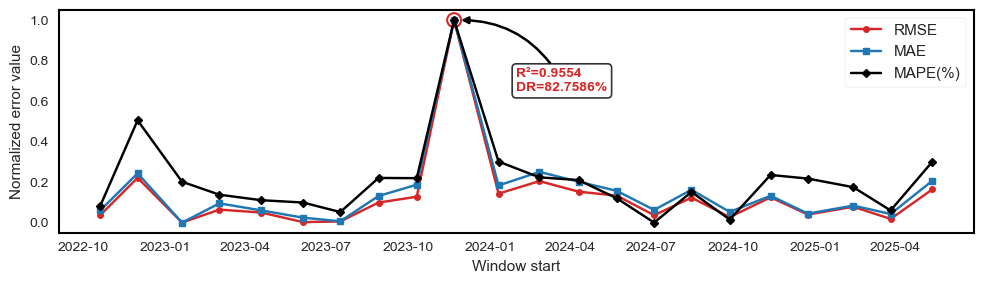

In [3]:
plt.figure(figsize=(10, 3))
for col, c, m in zip(error_cols, colors, markers):
    col_values = results_df[col].values
    norm_values = (col_values - np.min(col_values)) / (np.max(col_values) - np.min(col_values))
    plt.plot(
        results_df["窗口起点"],
        norm_values,
        label=col,
        color=c,
        marker=m,
        markersize=4,
        markeredgewidth=1
    )

norm_max_mape_val = (max_mape_val - np.min(results_df["MAPE(%)"])) / \
                    (np.max(results_df["MAPE(%)"]) - np.min(results_df["MAPE(%)"]))

plt.scatter(max_mape_x, norm_max_mape_val, color='red', facecolors='none', edgecolors='tab:red', s=100, linewidth=1.5)

plt.annotate(
    f"R²={max_r2_val:.4f}\nDR={max_dr_val:.4f}%",  
    xy=(max_mape_x, norm_max_mape_val),  
    xytext=(max_mape_x + pd.Timedelta(days=70), norm_max_mape_val - 0.3), 
    arrowprops=dict(
        arrowstyle="-|>",          
        color='black',               
        lw=1.8,                    
        shrinkA=0, shrinkB=5,       
        connectionstyle="arc3,rad=0.3"  
    ),
    fontweight='bold',
    fontsize=10,
    color='tab:red',  
    ha='left',
    va='center',
    bbox=dict(
        boxstyle="round,pad=0.3",    
        facecolor="white",           
        edgecolor="black",           
        linewidth=1.2,              
        alpha=0.8                   
    )
)

plt.legend(frameon=True, facecolor='white', fontsize=11)
plt.xlabel("Window start")
plt.ylabel("Normalized error value")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig16.pdf', format='pdf', dpi=300)
plt.show()

In [66]:
from scipy.stats import levene

mid = len(results_df) // 2
stat, p = levene(results_df["RMSE"][:mid], results_df["RMSE"][mid:])
print(f"Levene’s test p={p}")

Levene’s test p=0.321002099659564


In [31]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, DotProduct, ExpSineSquared, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

path_ceemdan = r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN.xlsx'
data = pd.read_excel(path_ceemdan, sheet_name='Sheet1')

high_freq = data.iloc[:, 1].values 
low_freq = data.iloc[:, 2].values  

path_bdi = r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx'
bdi_df = pd.read_excel(path_bdi)
time_real = pd.to_datetime(bdi_df.iloc[:, 0])
real_bdi = bdi_df.iloc[:, 1].values

n_obs = len(real_bdi)

def create_dataset(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps].flatten())
        y.append(series[i + n_steps])
    return np.array(X), np.array(y)

def gpr_predict_high(train_series, test_series, n_steps=5):
    sigma = 1.0
    train_series = gaussian_filter1d(train_series.flatten(), sigma=sigma).reshape(-1,1)
    test_series = gaussian_filter1d(test_series.flatten(), sigma=sigma).reshape(-1,1)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_series)
    test_scaled = scaler.transform(test_series)

    X_train, y_train = create_dataset(train_scaled, n_steps)
    test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
    X_test, y_test = create_dataset(test_extended, n_steps)

    best_kernel = ConstantKernel(4.807) * Matern(length_scale=0.534, nu=0.5) + WhiteKernel(noise_level=0.2877)
    gpr = GaussianProcessRegressor(kernel=best_kernel, alpha=0.05, random_state=42)
    gpr.fit(X_train, y_train)

    y_pred_train = scaler.inverse_transform(gpr.predict(X_train).reshape(-1,1)).flatten()
    y_pred_test  = scaler.inverse_transform(gpr.predict(X_test).reshape(-1,1)).flatten()

    return y_pred_train, y_pred_test

def gpr_predict_low(train_series, test_series, n_steps=5):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_series.reshape(-1,1))
    test_scaled  = scaler.transform(test_series.reshape(-1,1))

    X_train, y_train = create_dataset(train_scaled, n_steps)
    test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
    X_test, y_test = create_dataset(test_extended, n_steps)

    best_kernel = (ConstantKernel(2.350) * DotProduct()) * \
                  ExpSineSquared(length_scale=10.078, periodicity=2.943) + \
                  (ConstantKernel(3.289) * Matern(length_scale=0.941, nu=2.5)) + \
                  WhiteKernel(noise_level=0.722)

    gpr = GaussianProcessRegressor(kernel=best_kernel, alpha=0, random_state=42)
    gpr.fit(X_train, y_train)

    y_pred_train = scaler.inverse_transform(gpr.predict(X_train).reshape(-1,1)).flatten()
    y_pred_test  = scaler.inverse_transform(gpr.predict(X_test).reshape(-1,1)).flatten()

    return y_pred_train, y_pred_test

def stability_test(train_series, test_series, model_func, noise_levels=[0, 0.01, 0.05, 0.1, 0.2, 0.3], n_steps=5):
    results = {}
    for noise in noise_levels:
        noisy_test = test_series + np.random.normal(0, noise * np.std(test_series), size=test_series.shape)
        _, y_pred_noisy = model_func(train_series, noisy_test, n_steps=n_steps)
        results[noise] = y_pred_noisy
    return results

train_days = 365
test_days  = 30
n_steps    = 5
results_list = []
final_preds = []
final_times = []
final_reals = []

noise_results_list = []

for start in range(0, n_obs - train_days - test_days + 1, 30):
    train_high = high_freq[start:start+train_days]
    test_high  = high_freq[start+train_days:start+train_days+test_days]
    train_low  = low_freq[start:start+train_days]
    test_low   = low_freq[start+train_days:start+train_days+test_days]

    real_test  = real_bdi[start+train_days:start+train_days+test_days]
    time_test  = time_real[start+train_days:start+train_days+test_days]

    high_train_pred, high_test_pred = gpr_predict_high(train_high, test_high, n_steps=n_steps)
    low_train_pred,  low_test_pred  = gpr_predict_low(train_low, test_low, n_steps=n_steps)
    combined_test_pred = high_test_pred + low_test_pred

    rmse = np.sqrt(mean_squared_error(real_test, combined_test_pred))
    mae  = mean_absolute_error(real_test, combined_test_pred)
    mape = np.mean(np.abs((real_test - combined_test_pred) / (real_test + 1e-8))) * 100
    r2   = r2_score(real_test, combined_test_pred)
    dr   = np.mean(np.sign(np.diff(real_test) + 1e-6) == np.sign(np.diff(combined_test_pred))) * 100

    results_list.append((time_test.iloc[0], rmse, mae, mape, r2, dr))

    noise_levels = [0, 0.01, 0.05, 0.1, 0.2, 0.3]
    stability_results_high = stability_test(train_high, test_high, gpr_predict_high,
                                            noise_levels=noise_levels, n_steps=n_steps)
    _, low_test_pred_no_noise = gpr_predict_low(train_low, test_low, n_steps=n_steps)

    for noise in noise_levels:
        combined_pred = stability_results_high[noise] + low_test_pred_no_noise
        rmse_noise = np.sqrt(mean_squared_error(real_test, combined_pred))
        mae_noise  = mean_absolute_error(real_test, combined_pred)
        mape_noise = np.mean(np.abs((real_test - combined_pred) / (real_test + 1e-8))) * 100
        r2_noise   = r2_score(real_test, combined_pred)
        dr_noise   = np.mean(np.sign(np.diff(real_test) + 1e-6) == np.sign(np.diff(combined_pred))) * 100

        noise_results_list.append({
            "噪声水平": noise,
            "RMSE": rmse_noise,
            "MAE": mae_noise,
            "MAPE(%)": mape_noise,
            "R²": r2_noise,
            "DR(%)": dr_noise
        })



E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
E:\Anaconda\envs\py3921\lib\site-packages\sklearn\gaussian_process\kernels.py:420: 

In [32]:
noise_df = pd.DataFrame(noise_results_list)
stats_df = noise_df.groupby("噪声水平").agg({
    "RMSE": ["mean", "std", "min", "max"],
    "MAE": ["mean", "std", "min", "max"],
    "MAPE(%)": ["mean", "std", "min", "max"],
    "R²": ["mean", "std", "min", "max"],
    "DR(%)": ["mean", "std", "min", "max"]
})
cv_df = noise_df.groupby("噪声水平").apply(lambda x: x.std() / x.mean())
for metric in ["RMSE", "MAE", "MAPE(%)", "R²", "DR(%)"]:
    stats_df[(metric, "CV")] = cv_df[metric]
stats_df = stats_df.stack(level=1).reset_index()
stats_df.rename(columns={"level_1": "指标"}, inplace=True)
final_stats = stats_df[["噪声水平", "指标", "RMSE", "MAE", "MAPE(%)", "R²", "DR(%)"]]
indicator_order = ["mean", "std", "min", "max", "CV"]
final_stats["指标"] = pd.Categorical(final_stats["指标"], categories=indicator_order, ordered=True)
final_stats = final_stats.sort_values(["噪声水平", "指标"]).reset_index(drop=True)
baseline = final_stats[final_stats["噪声水平"] == 0].set_index("指标")

for col in ["RMSE", "MAE"]:
    diffs = []
    for idx, row in final_stats.iterrows():
        noise = row["噪声水平"]
        indicator = row["指标"]
        if noise == 0:
            diffs.append("")
        else:
            base_val = baseline.loc[indicator, col]
            diff = (row[col] - base_val) / base_val * 100
            diffs.append(f"{diff:+.4f}%")
    final_stats[f"{col}(±%)"] = diffs
fixed_order = [
    "噪声水平", "指标",
    "RMSE", "RMSE(±%)",
    "MAE", "MAE(±%)",
    "MAPE(%)",
    "R²",
    "DR(%)"
]
final_stats = final_stats[fixed_order]
pd.set_option('display.float_format', '{:.4f}'.format)
print(final_stats)


     噪声水平    指标    RMSE  RMSE(±%)     MAE   MAE(±%)  MAPE(%)     R²   DR(%)
0  0.0000  mean 19.2147           14.6026             0.9221 0.9864 84.1693
1  0.0000   std 15.9816           10.7792             0.3912 0.0115  5.8923
2  0.0000   min  9.1175            6.4564             0.5269 0.9554 72.4138
3  0.0000   max 86.9926           59.3438             2.4012 0.9977 96.5517
4  0.0000    CV  0.8317            0.7382             0.4243 0.0117  0.0700
5  0.0100  mean 19.2124  -0.0120% 14.5987  -0.0270%   0.9219 0.9864 84.1693
6  0.0100   std 15.9870  +0.0338% 10.7615  -0.1642%   0.3903 0.0116  6.1739
7  0.0100   min  9.0960  -0.2353%  6.4506  -0.0892%   0.5267 0.9554 72.4138
8  0.0100   max 87.0149  +0.0257% 59.2656  -0.1318%   2.3970 0.9977 96.5517
9  0.0100    CV  0.8321  +0.0458%  0.7372  -0.1373%   0.4233 0.0117  0.0734
10 0.0500  mean 19.2485  +0.1759% 14.5608  -0.2861%   0.9186 0.9864 84.3260
11 0.0500   std 15.9766  -0.0308% 10.7281  -0.4742%   0.3884 0.0116  6.1801
12 0.0500   

C:\Users\h\AppData\Local\Temp\ipykernel_14960\284823045.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cv_df = noise_df.groupby("噪声水平").apply(lambda x: x.std() / x.mean())
C:\Users\h\AppData\Local\Temp\ipykernel_14960\284823045.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stats_df = stats_df.stack(level=1).reset_index()
